In [27]:
import pandas as pd 
users = pd.read_csv("users_data.csv") 
cards = pd.read_csv("cards_data.csv") 
transactions = pd.read_csv("transactions_data.csv")

In [107]:
cards.columns

Index(['id', 'client_id', 'card_brand', 'card_type', 'card_number', 'expires',
       'cvv', 'has_chip', 'num_cards_issued', 'credit_limit', 'acct_open_date',
       'year_pin_last_changed', 'card_on_dark_web'],
      dtype='str')

In [97]:
transactions

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
13305910,23761868,2019-10-31 23:56:00,1718,2379,$1.11,Chip Transaction,86438,West Covina,CA,91792.0,5499,NaN
13305911,23761869,2019-10-31 23:56:00,1766,2066,$12.80,Online Transaction,39261,ONLINE,NaN,NaN,5815,NaN
13305912,23761870,2019-10-31 23:57:00,199,1031,$40.44,Swipe Transaction,2925,Allen,TX,75002.0,4900,NaN
13305913,23761873,2019-10-31 23:58:00,1986,5443,$4.00,Chip Transaction,46284,Daly City,CA,94014.0,5411,NaN


In [22]:
import networkx as nx

In [95]:
transactions.columns

Index(['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'errors'],
      dtype='str')

In [24]:
# B = nx.Graph()
# B.add_nodes_from(transactions["client_id"].unique(), bipartite=0)
# B.add_nodes_from(transactions["merchant_id"].unique(), bipartite=1)

In [31]:
agg = (
    transactions.groupby(["client_id","merchant_id"])
    .agg(
        tx_count=("id", "count"),
        total_amount=("amount","sum")
    )
    .reset_index()

)

B = nx.Graph()

clients = agg["client_id"].unique()
merchants = agg["merchant_id"].unique()

In [33]:
B.add_nodes_from(clients,bipartite=0,node_type="client")
B.add_nodes_from(merchants,bipartite=1,node_type="merchant")

In [35]:
#adding edges

for _, row in agg.iterrows():
    B.add_edge(
        row["client_id"],
        row["merchant_id"],
        tx_count=row["tx_count"],
        total_amount=row["total_amount"]
    )

In [40]:
from networkx.algorithms import bipartite

merchant_nodes = [n for n, d in B.nodes(data=True) if d["node_type"] == "merchant"]

G_merchants = bipartite.weighted_projected_graph(B,merchant_nodes)

In [65]:
def recommend_merchants_for_client(client_id, B, G_merchants, top_k=10):
    neighbors = list(B.neighbors(client_id))
    known_merchants = set(
        m for m in neighbors if B.nodes[m].get("node_type") == "merchant"
    )

    scores = {}

    for m in known_merchants:
        if m not in G_merchants:
            continue
        for nbr, edge_data in G_merchants[m].items():
            if nbr in known_merchants:
                continue
            w = edge_data.get("weight", 1.0)
            scores[nbr] = scores.get(nbr,0) + w

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]


example_client =agg["client_id"].iloc[0]

In [56]:
agg

,client_id,merchant_id,tx_count,total_amount
0,0,162,2,$4.37$5.94
1,0,212,1,$76.76
2,0,887,6,$8.38$7.73$9.73$12.65$8.92$8.63
3,0,1017,1,$7.34
4,0,1146,3,$27.93$29.53$23.80
...,...,...,...,...
357692,1998,94625,1,$22.85
357693,1998,94989,2,$17.05$15.34
357694,1998,96325,136,$92.43$89.78$109.70$107.71$92.83$112.56$96.01$...
357695,1998,99312,173,$0.75$16.02$4.39$4.11$5.62$12.74$3.93$7.61$18....


In [70]:
recommendations = recommend_merchants_for_client(1, B, G_merchants,top_k=10)

In [93]:
client_id = 1

neighbors = list(B.neighbors(client_id))
known_merchants = [m for m in neighbors if B.nodes[m]["node_type"] == "merchant"]

recommendations = recommend_merchants_for_client(client_id, B, G_merchants, top_k=5)
recommended_merchants = [m for m, _ in recommendations]
import matplotlib.pyplot as plt

H = nx.Graph()

# Add client
H.add_node(client_id, node_type="client")

# Add known merchants
for m in known_merchants:
    H.add_node(m, node_type="known")
    H.add_edge(client_id, m)

# Add recommended merchants
for m in recommended_merchants:
    H.add_node(m, node_type="recommended")

    # connect recommendation to similar merchants
    for km in known_merchants:
        if G_merchants.has_edge(m, km):
            H.add_edge(m, km)

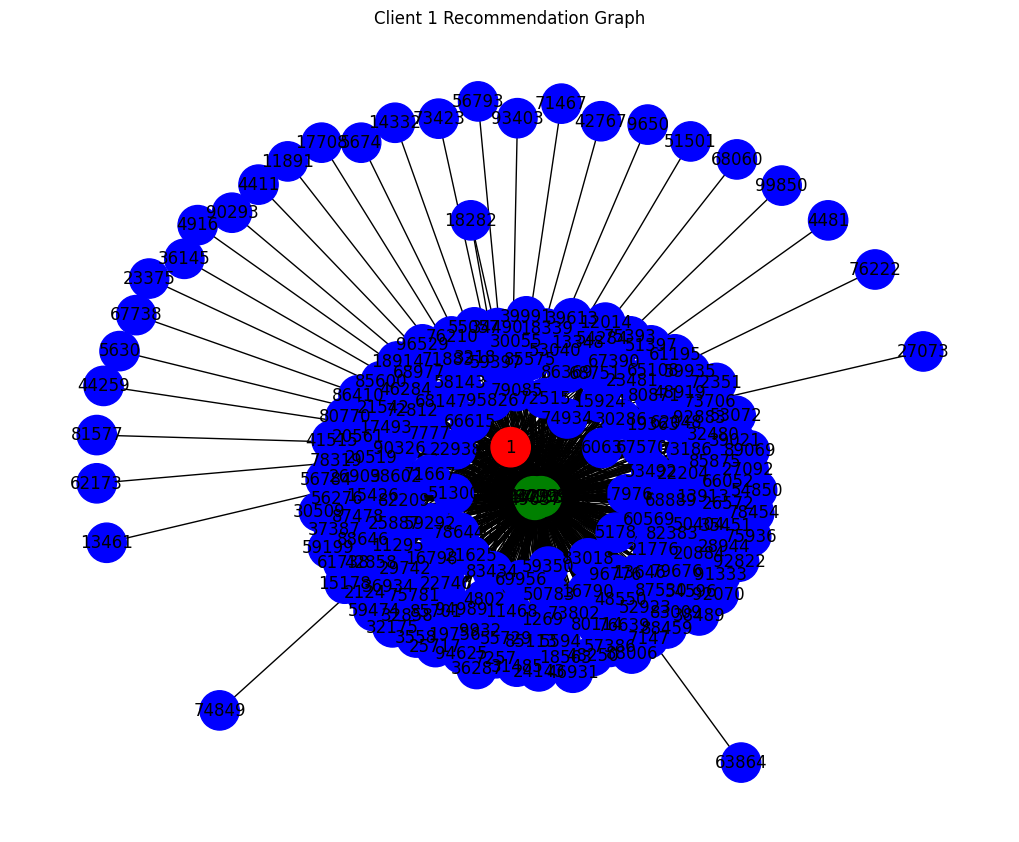

In [94]:
pos = nx.spring_layout(H, seed=42)

node_colors = []
for n in H.nodes():
    if H.nodes[n]["node_type"] == "client":
        node_colors.append("red")
    elif H.nodes[n]["node_type"] == "known":
        node_colors.append("blue")
    else:
        node_colors.append("green")

plt.figure(figsize=(10,8))
nx.draw(
    H,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=800
)

plt.title(f"Client {client_id} Recommendation Graph")
plt.show()

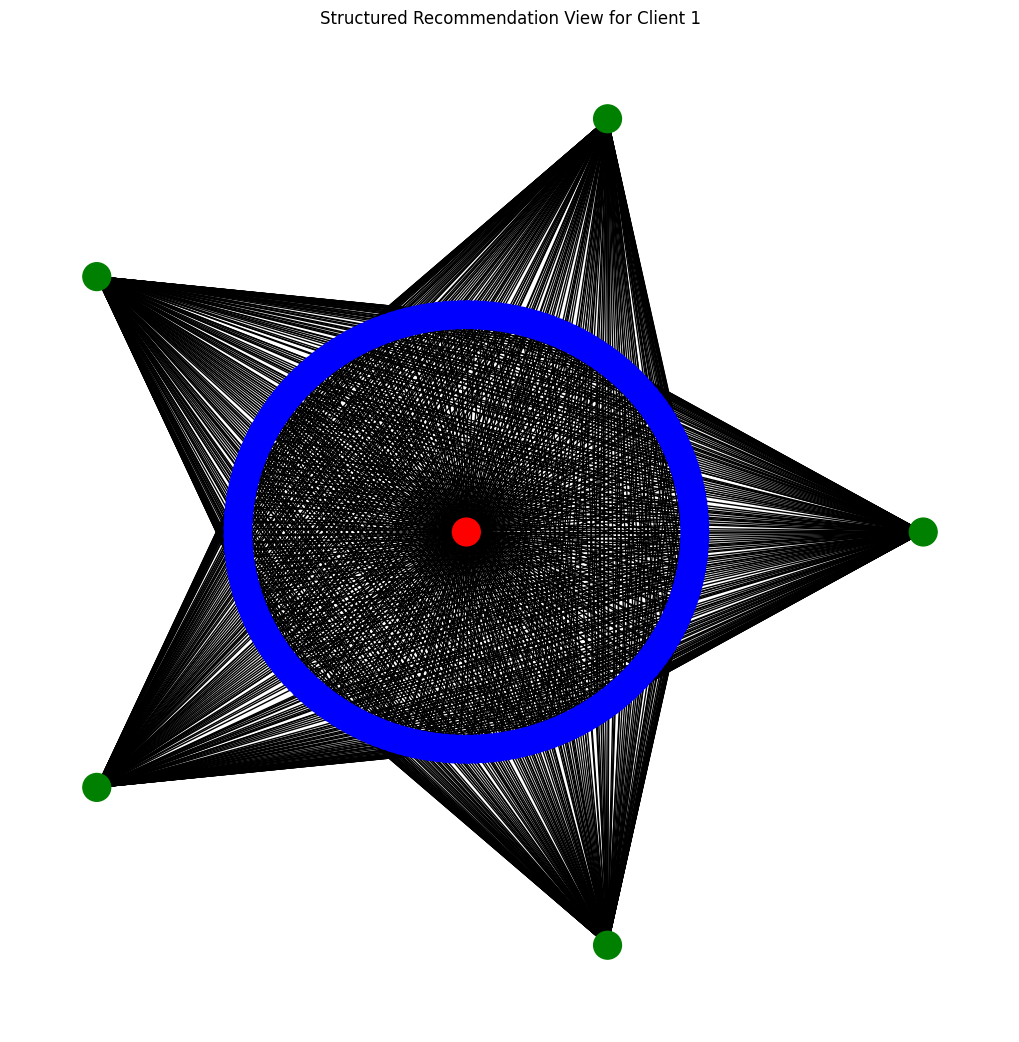

In [96]:
import numpy as np
import matplotlib.pyplot as plt

H = nx.Graph()

H.add_node(client_id, node_type="client")

for m in known_merchants:
    H.add_node(m, node_type="known")
    H.add_edge(client_id, m)

for m in recommended_merchants:
    H.add_node(m, node_type="recommended")
    for km in known_merchants:
        if G_merchants.has_edge(m, km):
            H.add_edge(m, km)

# ---- Custom Layout ----
pos = {}

# Client in center
pos[client_id] = np.array([0, 0])

# Known merchants in inner circle
radius_inner = 3
angle_step = 2 * np.pi / len(known_merchants)

for i, m in enumerate(known_merchants):
    angle = i * angle_step
    pos[m] = np.array([
        radius_inner * np.cos(angle),
        radius_inner * np.sin(angle)
    ])

# Recommended merchants in outer circle
radius_outer = 6
if recommended_merchants:
    angle_step = 2 * np.pi / len(recommended_merchants)

    for i, m in enumerate(recommended_merchants):
        angle = i * angle_step
        pos[m] = np.array([
            radius_outer * np.cos(angle),
            radius_outer * np.sin(angle)
        ])

# Colors
node_colors = []
for n in H.nodes():
    if H.nodes[n]["node_type"] == "client":
        node_colors.append("red")
    elif H.nodes[n]["node_type"] == "known":
        node_colors.append("blue")
    else:
        node_colors.append("green")

plt.figure(figsize=(10,10))
nx.draw(H, pos, node_color=node_colors, with_labels=False, node_size=400)
plt.title(f"Structured Recommendation View for Client {client_id}")
plt.show()

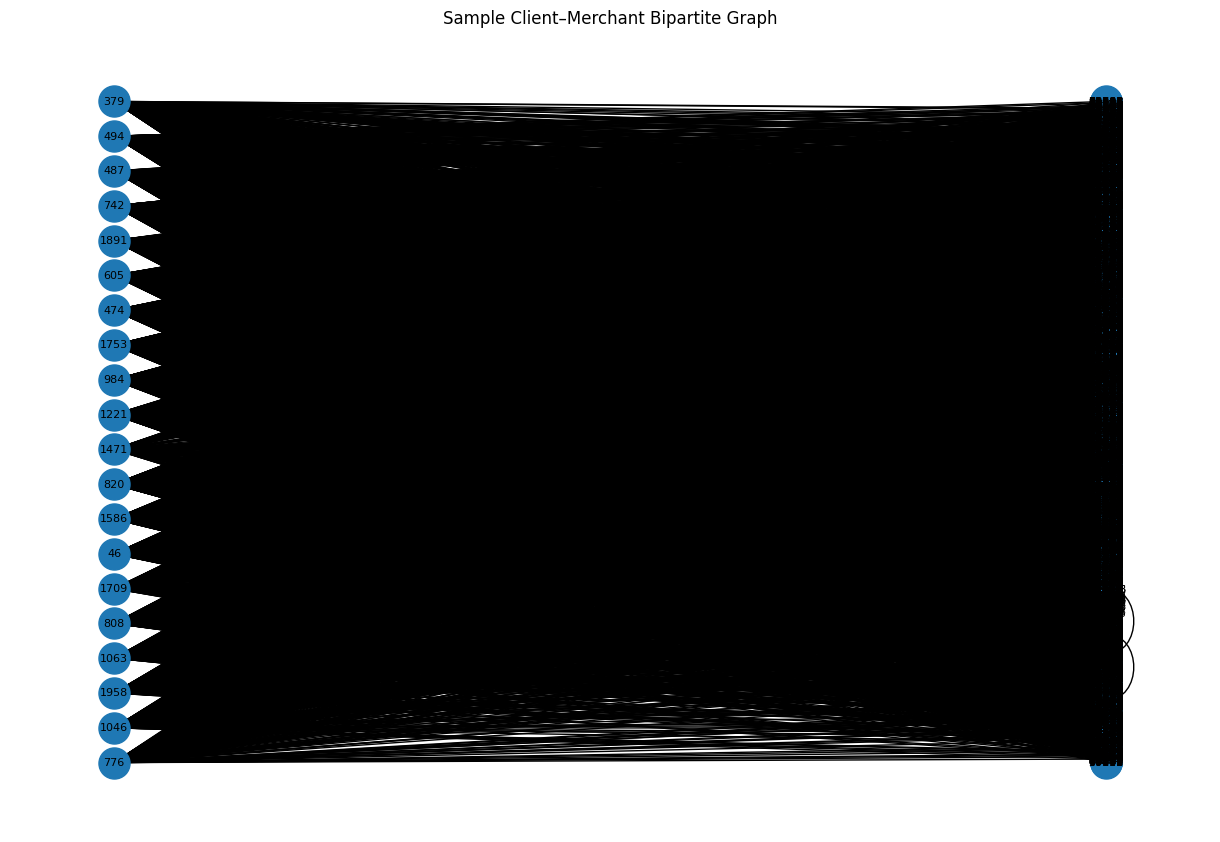

In [79]:
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite
import random

# Take small sample
sample_clients = random.sample(list(clients), min(20, len(clients)))
sample_merchants = set()

for c in sample_clients:
    sample_merchants.update(B.neighbors(c))

sub_nodes = list(sample_clients) + list(sample_merchants)
subgraph = B.subgraph(sub_nodes)

# Position bipartite layout
pos = nx.bipartite_layout(subgraph, sample_clients)

plt.figure(figsize=(12,8))
nx.draw(
    subgraph,
    pos,
    with_labels=True,
    node_size=500,
    font_size=8
)

plt.title("Sample Client–Merchant Bipartite Graph")
plt.show()

In [83]:
plt.figure(figsize=(10,8))

pos = nx.spring_layout(G_merchants, k=0.5)

nx.draw(
    G_merchants,
    pos,
    with_labels=False,
    node_size=50,
    edge_color="gray"
)

plt.title("Merchant–Merchant Projected Graph")
plt.show()

KeyboardInterrupt: 

<Figure size 1000x800 with 0 Axes>

KeyboardInterrupt: 

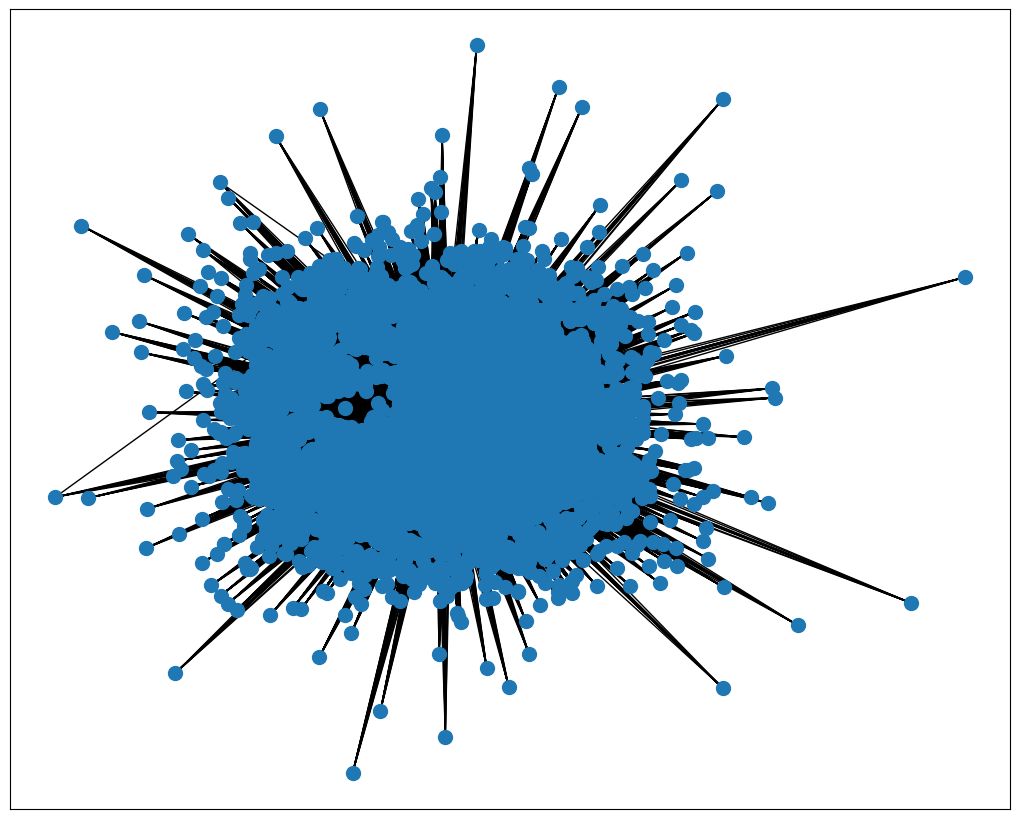

In [84]:
strong_edges = [(u,v) for u,v,d in G_merchants.edges(data=True) if d["weight"] > 5]
H = G_merchants.edge_subgraph(strong_edges)

plt.figure(figsize=(10,8))
pos = nx.spring_layout(H)
nx.draw(H, pos, node_size=100)
plt.title("Strong Merchant Connections")
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn]━━━━━ 2/3 [scikit-learn]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [87]:
from sklearn.metrics.pairwise import cosine_similarity

# Pivot table
interaction_matrix = agg.pivot_table(
    index="client_id",
    columns="merchant_id",
    values="total_amount",
    fill_value=0
)

TypeError: dtype 'str' does not support operation 'mean'

In [98]:
import json

with open("mcc_code.json", "r") as f:
    mcc_dict = json.load(f)

In [99]:
merchant_mcc = (
    transactions.groupby("merchant_id")["mcc"]
    .agg(lambda x: x.mode().iloc[0])
    .to_dict()
)

In [100]:
merchant_mcc

{1: 7922,
 2: 4900,
 3: 5912,
 5: 5411,
 9: 7922,
 13: 5812,
 14: 5921,
 15: 8043,
 16: 8011,
 17: 8111,
 19: 5813,
 20: 5411,
 21: 7230,
 22: 5812,
 23: 5193,
 24: 5813,
 25: 7996,
 27: 7832,
 29: 5621,
 31: 8021,
 32: 5912,
 33: 8021,
 34: 5411,
 35: 5310,
 36: 5261,
 37: 5411,
 39: 5812,
 40: 1711,
 41: 5921,
 44: 7832,
 45: 5411,
 46: 5310,
 47: 7011,
 48: 5655,
 50: 5812,
 53: 7349,
 54: 5411,
 57: 5812,
 58: 5411,
 60: 5812,
 61: 7011,
 62: 1711,
 63: 5813,
 64: 8021,
 68: 7832,
 70: 5192,
 71: 8021,
 72: 5921,
 73: 7538,
 74: 5193,
 76: 8041,
 77: 7538,
 78: 5094,
 79: 5921,
 80: 7538,
 81: 4900,
 84: 7230,
 88: 7011,
 89: 5813,
 90: 7011,
 91: 5655,
 92: 5912,
 93: 5932,
 94: 8011,
 97: 8049,
 98: 4121,
 100: 4111,
 101: 5411,
 103: 7210,
 104: 7230,
 105: 8111,
 106: 5411,
 108: 5712,
 109: 5300,
 110: 5094,
 111: 7349,
 112: 5813,
 113: 8021,
 114: 7349,
 115: 5912,
 117: 5411,
 118: 5300,
 119: 5812,
 120: 7349,
 121: 7349,
 122: 5211,
 124: 5813,
 125: 5912,
 126: 4121,
 12

In [101]:
example_client = agg["client_id"].iloc[0]

# Get known merchants
known_merchants = list(
    m for m in B.neighbors(example_client)
    if B.nodes[m].get("node_type") == "merchant"
)

# limit to 10
known_merchants = known_merchants[:10]

# Get recommended merchants
recommended_merchants = [
    m for m, _ in recommend_merchants_for_client(example_client, B, G_merchants, top_k=10)
]

In [102]:
H = nx.Graph()
client_id = example_client

H.add_node(client_id, node_type="client", label=f"Client {client_id}")

# ---- Known Merchants ----
for m in known_merchants:
    mcc_code = str(merchant_mcc.get(m, "Unknown"))
    mcc_desc = mcc_dict.get(mcc_code, "Unknown MCC")

    label = f"{m}\n{mcc_desc}"

    H.add_node(m, node_type="known", label=label)
    H.add_edge(client_id, m)

# ---- Recommended Merchants ----
for m in recommended_merchants:
    mcc_code = str(merchant_mcc.get(m, "Unknown"))
    mcc_desc = mcc_dict.get(mcc_code, "Unknown MCC")

    label = f"{m}\n{mcc_desc}"

    H.add_node(m, node_type="recommended", label=label)

    for km in known_merchants:
        if G_merchants.has_edge(m, km):
            H.add_edge(m, km)

In [103]:
pos = {}
pos[client_id] = np.array([0, 0])

# inner circle
radius_inner = 4
angle_step = 2 * np.pi / len(known_merchants)

for i, m in enumerate(known_merchants):
    angle = i * angle_step
    pos[m] = np.array([
        radius_inner * np.cos(angle),
        radius_inner * np.sin(angle)
    ])

# outer circle
radius_outer = 8
angle_step = 2 * np.pi / len(recommended_merchants)

for i, m in enumerate(recommended_merchants):
    angle = i * angle_step
    pos[m] = np.array([
        radius_outer * np.cos(angle),
        radius_outer * np.sin(angle)
    ])

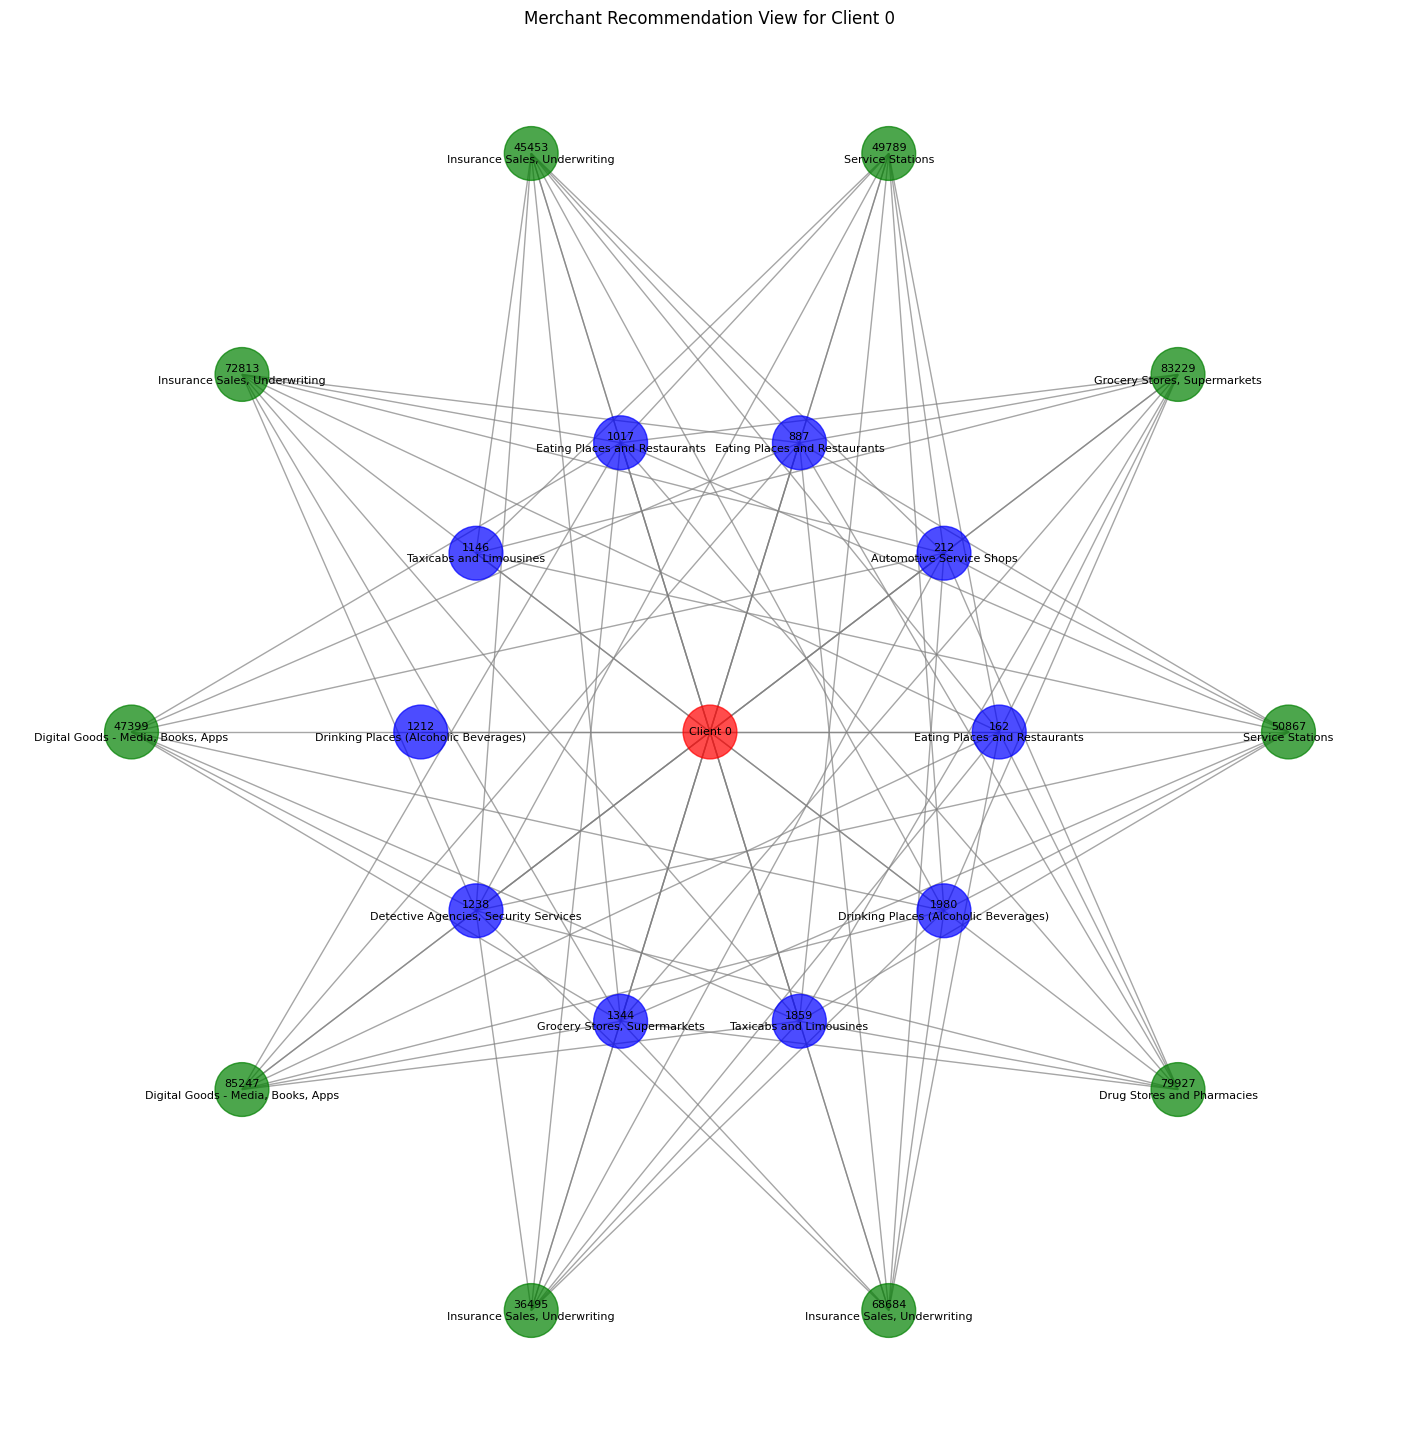

In [104]:
labels = nx.get_node_attributes(H, "label")

node_colors = []
for n in H.nodes():
    if H.nodes[n]["node_type"] == "client":
        node_colors.append("red")
    elif H.nodes[n]["node_type"] == "known":
        node_colors.append("blue")
    else:
        node_colors.append("green")

plt.figure(figsize=(14,14))

nx.draw(
    H,
    pos,
    node_color=node_colors,
    node_size=1500,
    with_labels=False,
    edge_color="gray",
    alpha=0.7
)

nx.draw_networkx_labels(
    H,
    pos,
    labels=labels,
    font_size=8
)

plt.title(f"Merchant Recommendation View for Client {client_id}")
plt.axis("off")
plt.show()